In [71]:
from os.path import join
import pandas as pd
from omegaconf import OmegaConf

dfs = []
root = "/home/ki/projects/work/mln-ood/gtsrb/multirun/2025-05-20/13-05-38/"

for d in range(6):
    d = str(d)
    path = join(root, d, "results.csv")
    df = pd.read_csv(path)

    df = df[df.Method.isin(["MLN+Ensemble", "MLN+ViM"])]
    path = join(root, d, "results.csv")
    cfg = OmegaConf.load(join(root, d, ".hydra", "config.yaml"))
    df["Distribution"] = cfg.fit_score_dist.title()
    dfs.append(df)


In [72]:
import numpy as np
df = pd.concat(dfs)
# set(dfs[0].Method)

(50.0, 100.0)

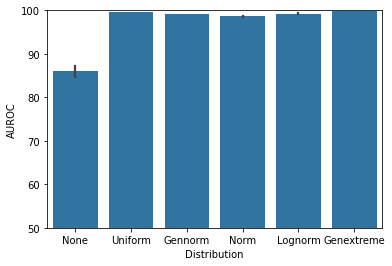

In [73]:
import seaborn as sb
import matplotlib.pyplot as plt


sb.barplot(df, x="Distribution", y="AUROC")
plt.ylim([50, 100])

In [74]:
df.groupby(["Distribution"])["AUROC"].agg(["mean", "sem"])

,mean,sem
Distribution,,
Genextreme,99.839200,0.008198
Gennorm,99.145950,0.040261
Lognorm,99.194828,0.048920
None,86.156572,0.626200
Norm,98.602174,0.040051
Uniform,99.611471,0.020105


In [75]:
df

,Unnamed: 0,AUROC,AUTC,AUPR-IN,AUPR-OUT,FPR95TPR,Dataset,Method,Seed,Distribution
12,0,89.802796,10.230316,93.050557,94.028831,100.000000,LSUNCrop,MLN+Ensemble,0,None
13,0,89.802796,10.230316,93.050557,94.028831,100.000000,LSUNCrop,MLN+ViM,0,None
32,0,85.642910,14.386013,90.736353,91.782290,100.000000,LSUNResize,MLN+Ensemble,0,None
33,0,85.642910,14.386013,90.736353,91.782290,100.000000,LSUNResize,MLN+ViM,0,None
52,0,86.784208,13.247010,91.345942,92.469239,100.000000,TinyImageNetCrop,MLN+Ensemble,0,None
...,...,...,...,...,...,...,...,...,...,...
1553,0,99.930781,28.682935,99.954736,99.901366,0.205859,iNaturalist,MLN+ViM,9,Genextreme
1572,0,99.959034,26.389232,99.996853,98.110336,0.055424,GaussianNoise,MLN+Ensemble,9,Genextreme
1573,0,99.984163,28.669780,99.999881,99.800801,0.031671,GaussianNoise,MLN+ViM,9,Genextreme
1592,0,99.959588,26.389608,99.996823,93.163317,0.055424,UniformNoise,MLN+Ensemble,9,Genextreme


In [76]:
d = df.groupby(["Distribution", "Method", "Seed"])["AUROC"].mean().reset_index().groupby(["Distribution", "Method"])["AUROC"].agg(["mean", "sem"])

In [77]:
d

mean       sem
Distribution Method                           
Genextreme   MLN+Ensemble  99.882689  0.013993
             MLN+ViM       99.795712  0.026696
Gennorm      MLN+Ensemble  98.666712  0.055735
             MLN+ViM       99.625188  0.048751
Lognorm      MLN+Ensemble  98.595506  0.056512
             MLN+ViM       99.794150  0.026531
None         MLN+Ensemble  86.156572  1.604917
             MLN+ViM       86.156572  1.604917
Norm         MLN+Ensemble  99.070914  0.064907
             MLN+ViM       98.133434  0.060011
Uniform      MLN+Ensemble  99.762989  0.052740
             MLN+ViM       99.459954  0.070958

In [78]:
print(d.to_latex()) # loat_format="{{:0.2f}}

\begin{tabular}{llrr}
\toprule
 &  & mean & sem \\
Distribution & Method &  &  \\
\midrule
\multirow[t]{2}{*}{Genextreme} & MLN+Ensemble & 99.882689 & 0.013993 \\
 & MLN+ViM & 99.795712 & 0.026696 \\
\cline{1-4}
\multirow[t]{2}{*}{Gennorm} & MLN+Ensemble & 98.666712 & 0.055735 \\
 & MLN+ViM & 99.625188 & 0.048751 \\
\cline{1-4}
\multirow[t]{2}{*}{Lognorm} & MLN+Ensemble & 98.595506 & 0.056512 \\
 & MLN+ViM & 99.794150 & 0.026531 \\
\cline{1-4}
\multirow[t]{2}{*}{None} & MLN+Ensemble & 86.156572 & 1.604917 \\
 & MLN+ViM & 86.156572 & 1.604917 \\
\cline{1-4}
\multirow[t]{2}{*}{Norm} & MLN+Ensemble & 99.070914 & 0.064907 \\
 & MLN+ViM & 98.133434 & 0.060011 \\
\cline{1-4}
\multirow[t]{2}{*}{Uniform} & MLN+Ensemble & 99.762989 & 0.052740 \\
 & MLN+ViM & 99.459954 & 0.070958 \\
\cline{1-4}
\bottomrule
\end{tabular}



In [79]:
help(d.to_latex)

Help on method to_latex in module pandas.core.generic:

to_latex(buf: 'FilePath | WriteBuffer[str] | None' = None, *, columns: 'Sequence[Hashable] | None' = None, header: 'bool_t | SequenceNotStr[str]' = True, index: 'bool_t' = True, na_rep: 'str' = 'NaN', formatters: 'FormattersType | None' = None, float_format: 'FloatFormatType | None' = None, sparsify: 'bool_t | None' = None, index_names: 'bool_t' = True, bold_rows: 'bool_t' = False, column_format: 'str | None' = None, longtable: 'bool_t | None' = None, escape: 'bool_t | None' = None, encoding: 'str | None' = None, decimal: 'str' = '.', multicolumn: 'bool_t | None' = None, multicolumn_format: 'str | None' = None, multirow: 'bool_t | None' = None, caption: 'str | tuple[str, str] | None' = None, label: 'str | None' = None, position: 'str | None' = None) -> 'str | None' method of pandas.core.frame.DataFrame instance
    Render object to a LaTeX tabular, longtable, or nested table.
    
    Requires ``\usepackage{{booktabs}}``.  The out